## Color manipulation and Noise reduction

In this section, we will explore two important aspects of image processing: color manipulation and noise reduction.

Color manipulation involves changing or enhancing the colors in an image to achieve specific visual effects or to prepare the image for further analysis. This can include converting between color spaces, adjusting brightness and contrast, or applying color filters.

Noise reduction, on the other hand, focuses on removing unwanted variations (noise) from an image that can occur due to factors like poor lighting or low-quality sensors. By reducing noise, we can improve image clarity and make it easier to detect meaningful features.

Together, these techniques form the foundation for many applications in photography, computer vision, and machine learning.

### Color manipulation

In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

In [2]:
def plot_image(images, title):

    if not isinstance(images, (list, tuple)):
        images = [images]
    if not isinstance(title, (list, tuple)):
        title = [title] * len(images)
    if len(images) != len(title):
        raise ValueError("Length of images and titles must match.")


    for i in range(len(images)):
        if len(images) == 1:
            plt.imshow(images[0], cmap='gray')
            plt.title(title[0])
            plt.axis('off')
        elif len(images) > 1:
            plt.subplot(2,2,i+1)
            plt.imshow(images[i], cmap='gray')
            plt.title(title[i])
            plt.axis('off')
        else:
            raise ValueError("Image must be a list or a single image.")


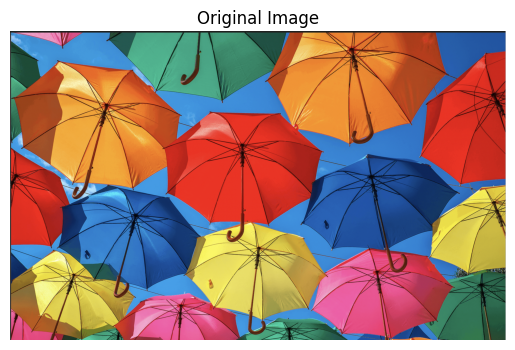

In [3]:
# Load the image
image = cv2.imread(r'C:\Users\96650\Desktop\techprojects\image-preprocessing-AlanoudAlqahtani\images\Screenshot.png')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
# Display the original image
plot_image(image,'Original Image')

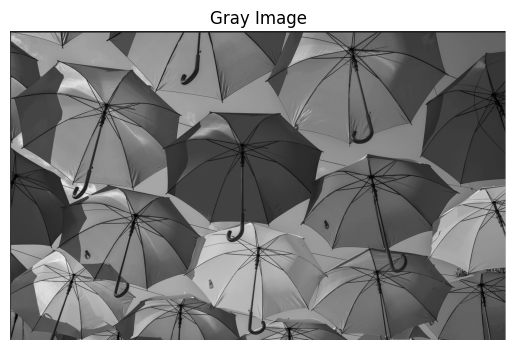

In [12]:
# gray the image
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
# show the gray image
plot_image(gray_image, 'Gray Image')

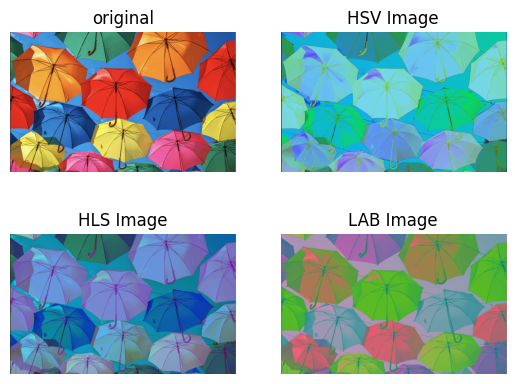

In [ ]:
hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)    # Convert to HSV
hls = cv2.cvtColor(image, cv2.COLOR_BGR2HLS)    # Convert to HLS
lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)    # Convert to LAB

# Display the converted images
plot_image([image,hsv, hls, lab], ['original','HSV Image', 'HLS Image', 'LAB Image'])



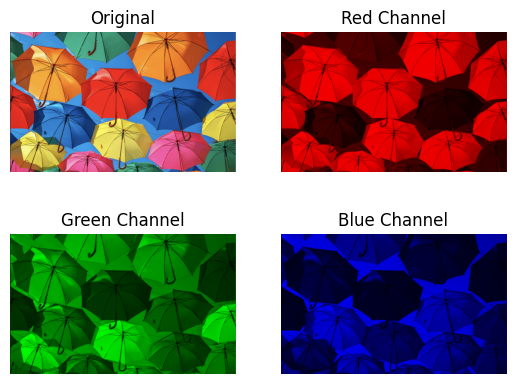

In [ ]:
copy_image = image.copy()
r, g, b = cv2.split(copy_image)

# Create a new image with only the red channel
red_image = cv2.merge([r, g * 0, b * 0])
green_image = cv2.merge([r * 0, g, b * 0])
blue_image = cv2.merge([r * 0, g * 0, b])

# Display the red, green, and blue channel images
plot_image([image,red_image, green_image, blue_image], ['Original','Red Channel', 'Green Channel', 'Blue Channel'])


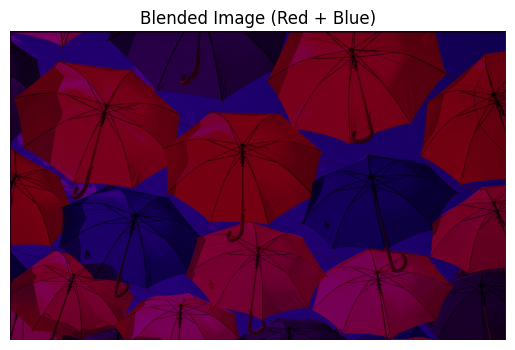

In [ ]:
blended = cv2.addWeighted(red_image, 0.5, blue_image, 0.5,0)
# Blend red and blue images arguments: (image1, alpha, image2, beta, gamma)
# where alpha and beta are the weights for the two images and gamma is a scalar added to the sum.
plot_image(blended, 'Blended Image (Red + Blue)')

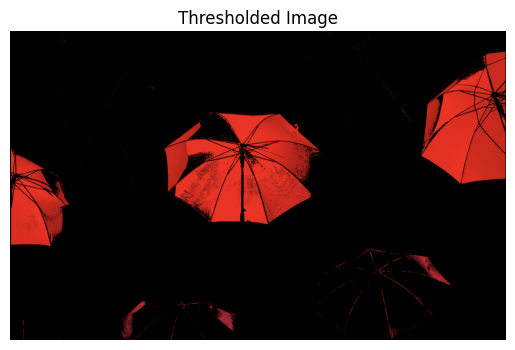

In [ ]:
threshold_value = cv2.inRange(image, (170, 0,0), (255, 55, 55))
mask = cv2.bitwise_and(image, image, mask=threshold_value)

# Show the thresholded image
plot_image(mask, 'Thresholded Image')

### Blurring / Smoothing

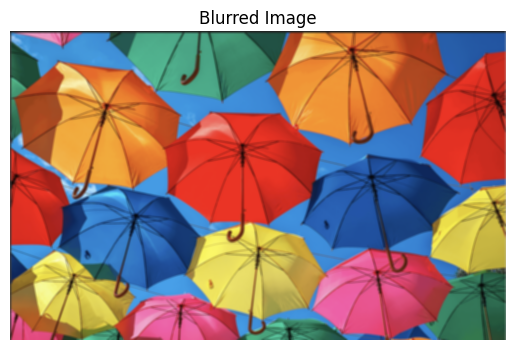

In [ ]:
blur = cv2.blur(image, (10, 10), 0)
plot_image(blur, 'Blurred Image')

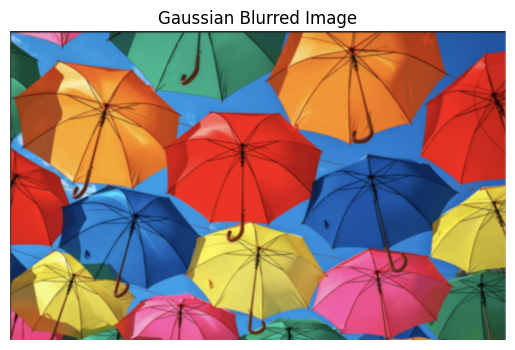

In [ ]:
blur2 = guassian_blur = cv2.GaussianBlur(image, (13, 13), 0)
plot_image(blur2, 'Gaussian Blurred Image')
# the difference between blur and gaussian blur is that gaussian blur uses a Gaussian kernel which gives more weight to the pixels closer to the center of the kernel,
# while the normal blur uses a uniform kernel.

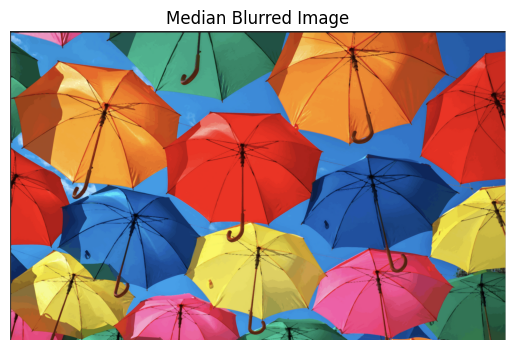

In [ ]:
median_blur = cv2.medianBlur(image, 5)
plot_image(median_blur, 'Median Blurred Image')
# median blur replaces each pixel with the median value of the pixels in a neighborhood around it, which is effective for removing salt-and-pepper noise.

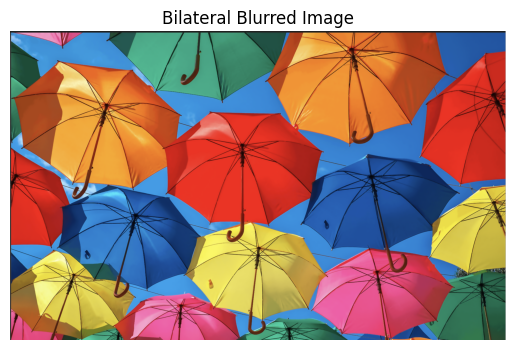

In [ ]:
bilateral_blur = cv2.bilateralFilter(image, 9, 75, 75)
plot_image(bilateral_blur, 'Bilateral Blurred Image')
# Bilateral blur is a more advanced technique that preserves edges while reducing noise,

### Contrast Improvement

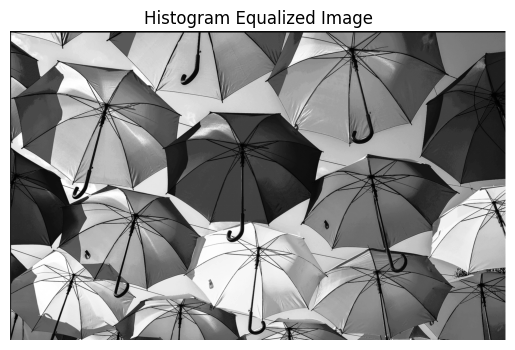

In [ ]:
histogram = cv2.equalizeHist(gray_image)
plot_image(histogram, 'Histogram Equalized Image')

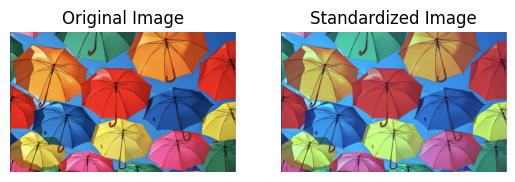

In [ ]:
mean, std = cv2.meanStdDev(image)
mean = mean.reshape(1, 1, 3) # Reshape mean to match the image dimensions
std = std.reshape(1, 1, 3) # Reshape std to match the image dimensions
std_img = (image - mean) / std # Standardize the image
std_img_display = np.clip(std_img * 64 + 128, 0, 255).astype(np.uint8) # Scale back to displayable range

plot_image([image, std_img_display], ['Original Image', 'Standardized Image'])


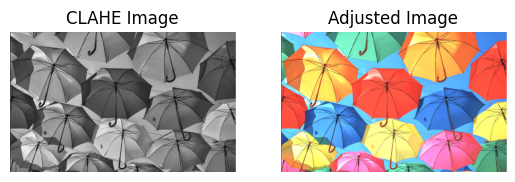

In [ ]:
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8)) # clipLimit controls contrast limit, tileGridSize controls the size of the grid for histogram equalization
clahe_image = clahe.apply(gray_image) # Apply CLAHE to the grayscale image

adjusted = cv2.convertScaleAbs(image, alpha=1.3, beta=20)

plot_image([clahe_image, adjusted], ['CLAHE Image', 'Adjusted Image'])

### Task 1

add random noise to an image then try to use filters to remove it


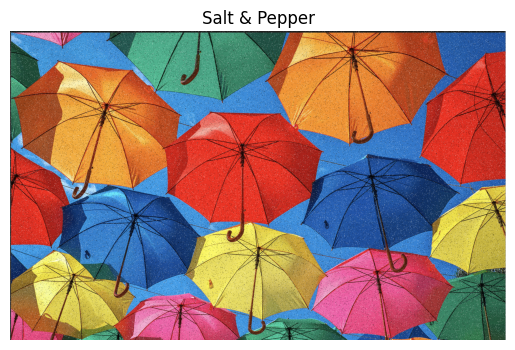

In [6]:
import numpy as np

def salt_pepper(img, amount=0.02):
    noisy = img.copy()
    
    h, w, c = img.shape
    num_pixels = int(amount * h * w)

    # Salt (white)
    coords = [
        np.random.randint(0, h, num_pixels),
        np.random.randint(0, w, num_pixels)
    ]
    noisy[coords[0], coords[1]] = 255

    # Pepper (black)
    coords = [
        np.random.randint(0, h, num_pixels),
        np.random.randint(0, w, num_pixels)
    ]
    noisy[coords[0], coords[1]] = 0

    return noisy


noisy_img = salt_pepper(image)

plot_image(
    [noisy_img],
    ['Salt & Pepper']
)
plt.show()

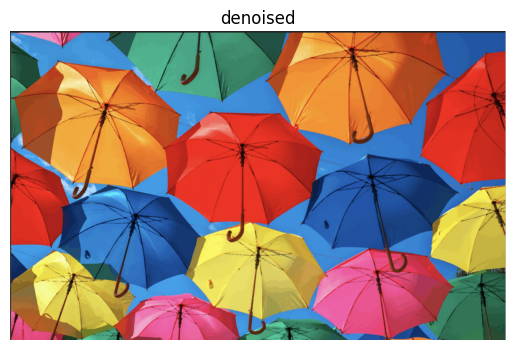

In [7]:
denoised = cv2.medianBlur(noisy_img, 5)
plot_image(
    [denoised],
    ['denoised']
)
plt.show()

### task 2

make only the red amprela are colorfull and anything else is gray

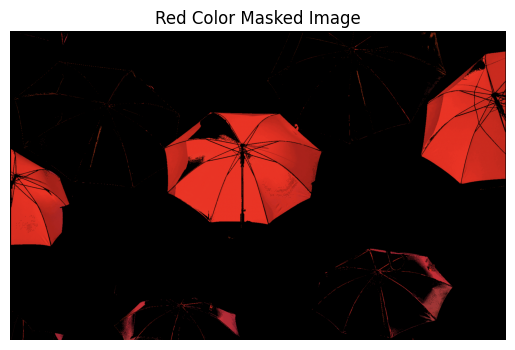

In [8]:
thresh= cv2.inRange(image, (150, 0, 0), (255, 58, 58))
# Threshold the image to isolate red colors
MASK = cv2.bitwise_and(image, image, mask=thresh)
plot_image(MASK, 'Red Color Masked Image')

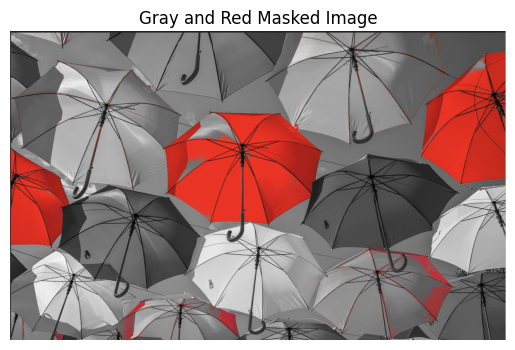

In [10]:
# Convert to grayscale and back to 3 channels

gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
gray_3ch = cv2.cvtColor(gray, cv2.COLOR_GRAY2RGB)
lower_red = np.array([150, 0, 0])
upper_red = np.array([255, 58, 58])
mask = cv2.inRange(image, lower_red, upper_red)
result = gray_3ch.copy()
result[mask > 0] = image[mask > 0]
plot_image(result, 'Gray and Red Masked Image')

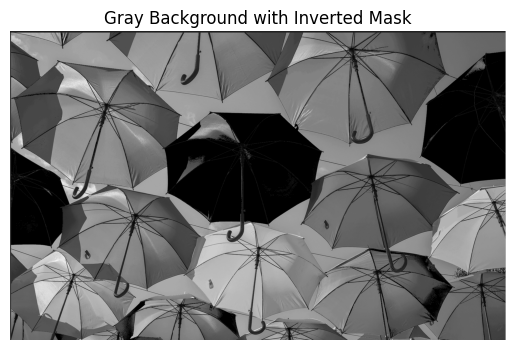

In [14]:
gray_3ch = cv2.cvtColor(gray_image, cv2.COLOR_GRAY2RGB)
mask = cv2.bitwise_not(thresh)
grayt = cv2.bitwise_and(gray_3ch, gray_3ch, mask=mask)

plot_image(grayt, 'Gray Background with Inverted Mask')

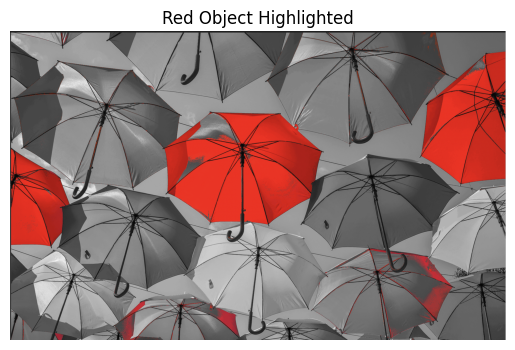

In [ ]:
img = image
mask_inv = cv2.bitwise_not(mask)
gray_background = cv2.bitwise_and(gray_3ch, gray_3ch, mask=mask_inv)
result = cv2.add(grayt, MASK)
plot_image(result, "Red Object Highlighted")